In [1]:
!pip install pandas scikit-learn seaborn

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('/content/diabetes.csv')

print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
X = data.drop('Outcome', axis=1)

y = data['Outcome']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7597402597402597


In [10]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6607142857142857


In [11]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6727272727272727


In [12]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6666666666666666


In [13]:
roc_auc = roc_auc_score(y_test, y_pred)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7404040404040404


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



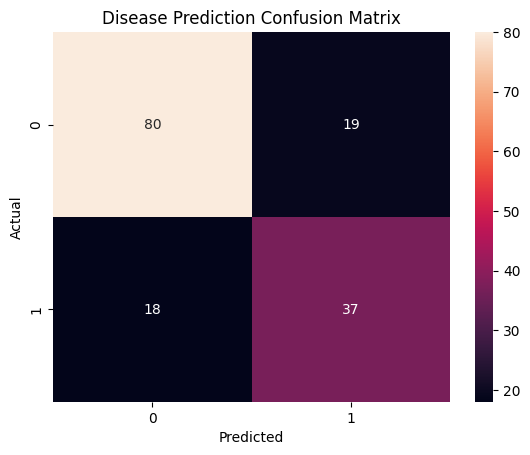

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Disease Prediction Confusion Matrix")

plt.show()

In [16]:
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Disease:", prediction[0])

Predicted Disease: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
